# Model Training with scikit-learn: Step-by-Step Tutorial

This notebook supports the lecture on **Model Training**. It focuses on:

- bias, variance, underfitting, and overfitting;
- L1, L2, and Elastic Net regularization;
- model = algorithm + hyperparameters;
- train/validation/test splitting;
- grid search and randomized search;
- k-fold and leave-one-out cross-validation;
- explainability, speed, and incremental learning.

## 0. Setup

Run this cell first. The notebook uses built-in scikit-learn datasets, so no external dataset download is required.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    LeaveOneOut,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve,
    validation_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup complete.")

Setup complete.


---
# Part A — Bias, Variance, Underfitting, and Overfitting

The lecture explains that a high-bias model often underfits, while a high-variance model often overfits. We demonstrate this with a non-linear regression problem.

## 1. Generate a non-linear regression dataset

A straight line is too simple for this data. A very high-degree polynomial may become too flexible.

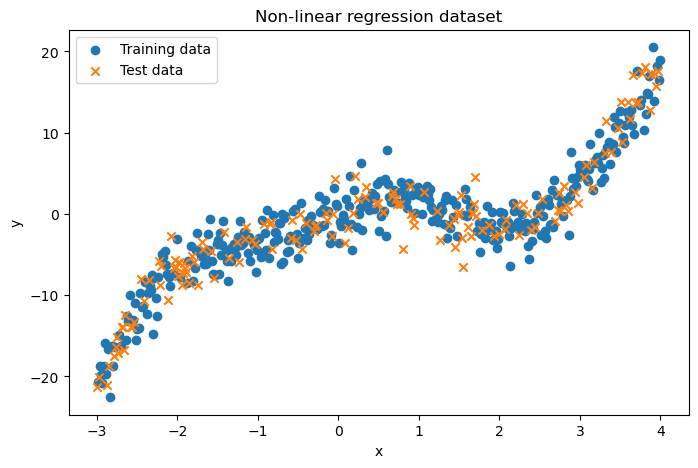

In [10]:
n_samples = 500
X = np.linspace(-3, 4, n_samples).reshape(-1, 1)
y_true = 0.5 * X.ravel() ** 3 - X.ravel() ** 2 + 2 * np.sin(2 * X.ravel())
y = y_true + np.random.normal(0, 2.0, size=n_samples)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

plt.figure(figsize=(8, 5))
plt.scatter(X_train_reg, y_train_reg, label="Training data")
plt.scatter(X_test_reg, y_test_reg, marker="x", label="Test data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Non-linear regression dataset")
plt.legend()
plt.show()

## 2. Fit polynomial models with different complexity

We fit three models:

- degree 1: underfitting candidate;
- degree 15: reasonable candidate;
- degree 30, 45: overfitting candidate.

In [11]:
def make_polynomial_regression(degree):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression()),
    ])

degrees = [1, 3, 15,30,45]
models = {}

for degree in degrees:
    model = make_polynomial_regression(degree)
    model.fit(X_train_reg, y_train_reg)
    models[degree] = model

    train_mse = mean_squared_error(y_train_reg, model.predict(X_train_reg))
    test_mse = mean_squared_error(y_test_reg, model.predict(X_test_reg))
    print(f"Degree {degree:>2} | Train MSE: {train_mse:8.3f} | Test MSE: {test_mse:8.3f}")

Degree  1 | Train MSE:   15.472 | Test MSE:   17.607
Degree  3 | Train MSE:    5.973 | Test MSE:    5.096
Degree 15 | Train MSE:    3.709 | Test MSE:    3.982
Degree 30 | Train MSE:    3.606 | Test MSE:    4.203
Degree 45 | Train MSE:    3.566 | Test MSE:    4.403


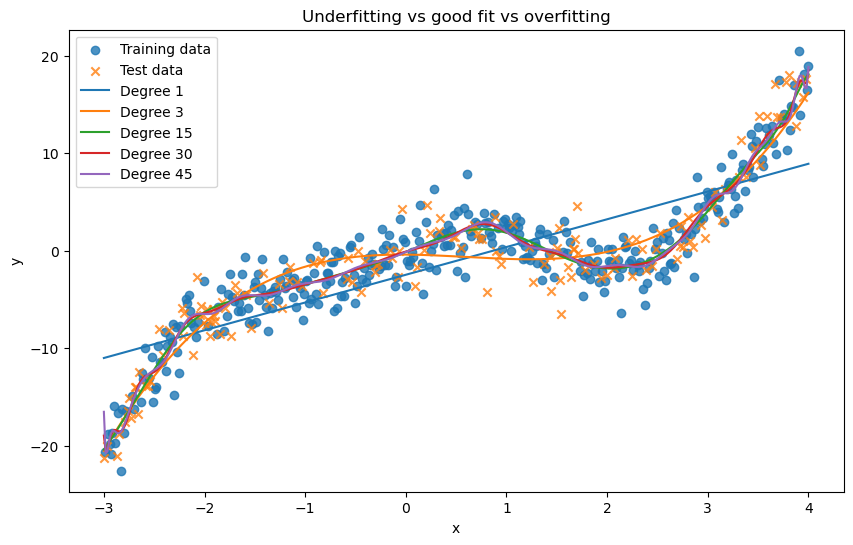

In [15]:
X_plot = np.linspace(-3, 4, 400).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_train_reg, y_train_reg, label="Training data", alpha=0.8)
plt.scatter(X_test_reg, y_test_reg, marker="x", label="Test data", alpha=0.8)

for degree, model in models.items():
    plt.plot(X_plot, model.predict(X_plot), label=f"Degree {degree}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Underfitting vs good fit vs overfitting")
plt.legend()
plt.show()

### Interpretation guide

- High training error and high test error: likely **underfitting**.
- Low training error but much higher test error: likely **overfitting**.
- A useful model balances training fit and generalization.

## 3. Learning curves

Learning curves compare training and validation performance as we increase the amount of training data.

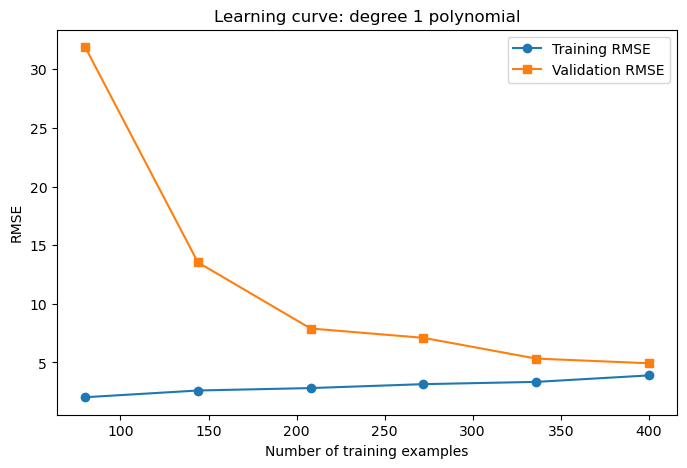

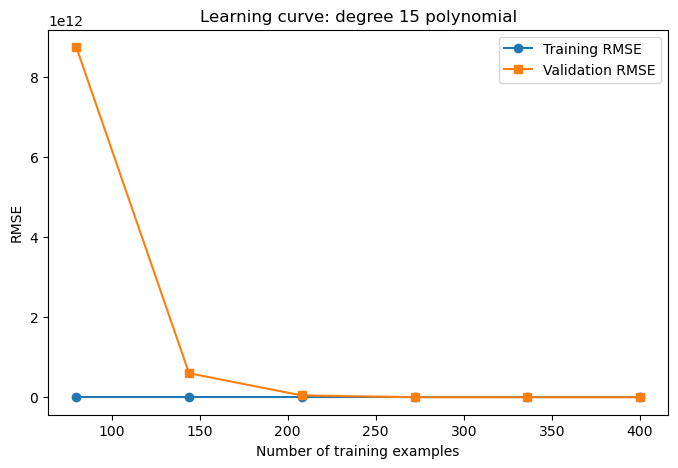

In [16]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X,
        y,
        train_sizes=np.linspace(0.2, 1.0, 6),
        cv=5,
        scoring="neg_mean_squared_error",
        n_jobs=1,
    )
    train_rmse = np.sqrt(-train_scores)
    valid_rmse = np.sqrt(-valid_scores)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_rmse.mean(axis=1), marker="o", label="Training RMSE")
    plt.plot(train_sizes, valid_rmse.mean(axis=1), marker="s", label="Validation RMSE")
    plt.xlabel("Number of training examples")
    plt.ylabel("RMSE")
    plt.title(title)
    plt.legend()
    plt.show()

plot_learning_curve(make_polynomial_regression(1), X, y, "Learning curve: degree 1 polynomial")
plot_learning_curve(make_polynomial_regression(15), X, y, "Learning curve: degree 15 polynomial")

---
# Part B — Regularization

Regularization constrains a model. In scikit-learn:

- `Ridge` = L2 regularization;
- `Lasso` = L1 regularization;
- `ElasticNet` = mixture of L1 and L2.

For these estimators, the regularization strength is controlled by `alpha`: higher `alpha` means stronger regularization.

## 4. Ridge regression: L2 regularization

In [17]:
ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_results = []

for alpha in ridge_alphas:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=False)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha)),
    ])
    model.fit(X_train_reg, y_train_reg)
    train_mse = mean_squared_error(y_train_reg, model.predict(X_train_reg))
    test_mse = mean_squared_error(y_test_reg, model.predict(X_test_reg))
    ridge_results.append((alpha, train_mse, test_mse))

print("Ridge results")
print("-" * 50)
for alpha, train_mse, test_mse in ridge_results:
    print(f"alpha={alpha:<7} | Train MSE={train_mse:8.3f} | Test MSE={test_mse:8.3f}")

Ridge results
--------------------------------------------------
alpha=0.001   | Train MSE=   3.731 | Test MSE=   3.940
alpha=0.01    | Train MSE=   3.777 | Test MSE=   3.864
alpha=0.1     | Train MSE=   3.977 | Test MSE=   3.759
alpha=1       | Train MSE=   4.416 | Test MSE=   3.834
alpha=10      | Train MSE=   4.862 | Test MSE=   4.217
alpha=100     | Train MSE=   7.062 | Test MSE=   7.024


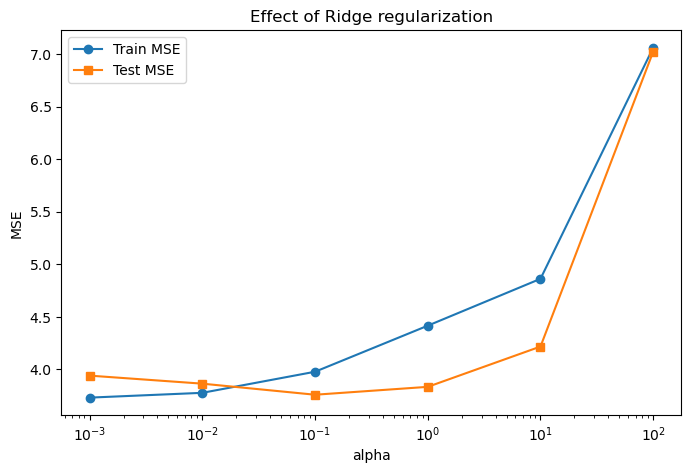

In [18]:
plt.figure(figsize=(8, 5))
plt.plot([r[0] for r in ridge_results], [r[1] for r in ridge_results], marker="o", label="Train MSE")
plt.plot([r[0] for r in ridge_results], [r[2] for r in ridge_results], marker="s", label="Test MSE")
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("MSE")
plt.title("Effect of Ridge regularization")
plt.legend()
plt.show()

## 5. Lasso regression: L1 regularization

Lasso can shrink some coefficients to exactly zero. This can support feature selection.

In [19]:
lasso_alphas = [0.001, 0.01, 0.1, 1, 10]

print("Lasso results")
print("-" * 75)
for alpha in lasso_alphas:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=False)),
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=alpha, max_iter=10000)),
    ])
    model.fit(X_train_reg, y_train_reg)
    train_mse = mean_squared_error(y_train_reg, model.predict(X_train_reg))
    test_mse = mean_squared_error(y_test_reg, model.predict(X_test_reg))
    non_zero = np.sum(np.abs(model.named_steps["lasso"].coef_) > 1e-6)
    print(f"alpha={alpha:<7} | Train MSE={train_mse:8.3f} | Test MSE={test_mse:8.3f} | Non-zero coefficients={non_zero}")

Lasso results
---------------------------------------------------------------------------
alpha=0.001   | Train MSE=   3.795 | Test MSE=   3.810 | Non-zero coefficients=11
alpha=0.01    | Train MSE=   4.363 | Test MSE=   3.809 | Non-zero coefficients=6
alpha=0.1     | Train MSE=   4.947 | Test MSE=   4.495 | Non-zero coefficients=5
alpha=1       | Train MSE=  12.421 | Test MSE=  13.503 | Non-zero coefficients=2
alpha=10      | Train MSE=  47.228 | Test MSE=  62.522 | Non-zero coefficients=0


## 6. Elastic Net: combining L1 and L2

`l1_ratio` controls the mixture:

- `l1_ratio = 0`: mostly Ridge-like;
- `l1_ratio = 1`: Lasso-like;
- values between 0 and 1 mix both penalties.

In [20]:
elastic_settings = [
    {"alpha": 0.01, "l1_ratio": 0.2},
    {"alpha": 0.01, "l1_ratio": 0.5},
    {"alpha": 0.01, "l1_ratio": 0.8},
    {"alpha": 0.1, "l1_ratio": 0.5},
    {"alpha": 1.0, "l1_ratio": 0.5},
]

print("Elastic Net results")
print("-" * 70)
for params in elastic_settings:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=15, include_bias=False)),
        ("scaler", StandardScaler()),
        ("elastic", ElasticNet(alpha=params["alpha"], l1_ratio=params["l1_ratio"], max_iter=10000)),
    ])
    model.fit(X_train_reg, y_train_reg)
    train_mse = mean_squared_error(y_train_reg, model.predict(X_train_reg))
    test_mse = mean_squared_error(y_test_reg, model.predict(X_test_reg))
    print(f"alpha={params['alpha']:<5} | l1_ratio={params['l1_ratio']:<4} | Train MSE={train_mse:8.3f} | Test MSE={test_mse:8.3f}")

Elastic Net results
----------------------------------------------------------------------
alpha=0.01  | l1_ratio=0.2  | Train MSE=   4.627 | Test MSE=   3.973
alpha=0.01  | l1_ratio=0.5  | Train MSE=   4.586 | Test MSE=   3.944
alpha=0.01  | l1_ratio=0.8  | Train MSE=   4.558 | Test MSE=   3.915
alpha=0.1   | l1_ratio=0.5  | Train MSE=   5.332 | Test MSE=   4.880
alpha=1.0   | l1_ratio=0.5  | Train MSE=  11.758 | Test MSE=  13.182


---
# Part C — Model = Algorithm + Hyperparameters

A model is an algorithm plus a set of hyperparameters. Because there is no universally best algorithm, we compare multiple reasonable candidates.

## 7. Load a classification dataset

We use the Breast Cancer Wisconsin dataset from scikit-learn.

In [21]:
data = load_breast_cancer()
X_clf = data.data
y_clf = data.target

print("Feature matrix shape:", X_clf.shape)
print("Target vector shape:", y_clf.shape)
print("Class names:", data.target_names)
print("First five feature names:", data.feature_names[:5])

Feature matrix shape: (569, 30)
Target vector shape: (569,)
Class names: ['malignant' 'benign']
First five feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


## 8. Create training, validation, and test sets

The validation set is used for model selection. The test set is used only once at the end.

In [22]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_clf, y_clf, test_size=0.15, stratify=y_clf, random_state=RANDOM_STATE
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,
    stratify=y_train_val,
    random_state=RANDOM_STATE,
)

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)
print("Test set:", X_test.shape)

Training set: (397, 30)
Validation set: (86, 30)
Test set: (86, 30)


## 9. Compare candidate algorithms with holdout validation

Scaling is placed inside a `Pipeline` to prevent data leakage.

In [23]:
candidate_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "SVM RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1),
}

validation_results = []
for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    valid_acc = accuracy_score(y_valid, model.predict(X_valid))
    validation_results.append((name, train_acc, valid_acc))

print("Algorithm comparison")
print("-" * 70)
for name, train_acc, valid_acc in validation_results:
    print(f"{name:<22} | Train accuracy={train_acc:.3f} | Validation accuracy={valid_acc:.3f}")

Algorithm comparison
----------------------------------------------------------------------
Logistic Regression    | Train accuracy=0.987 | Validation accuracy=1.000
KNN                    | Train accuracy=0.975 | Validation accuracy=0.977
SVM RBF                | Train accuracy=0.985 | Validation accuracy=0.988
Decision Tree          | Train accuracy=0.985 | Validation accuracy=0.977
Random Forest          | Train accuracy=1.000 | Validation accuracy=0.965


## 10. Final test evaluation

After model selection, retrain the chosen model on training + validation data. Then evaluate it on the test set.

Best validation model: Logistic Regression
Final test accuracy: 0.9767

              precision    recall  f1-score   support

   malignant       0.97      0.97      0.97        32
      benign       0.98      0.98      0.98        54

    accuracy                           0.98        86
   macro avg       0.98      0.98      0.98        86
weighted avg       0.98      0.98      0.98        86



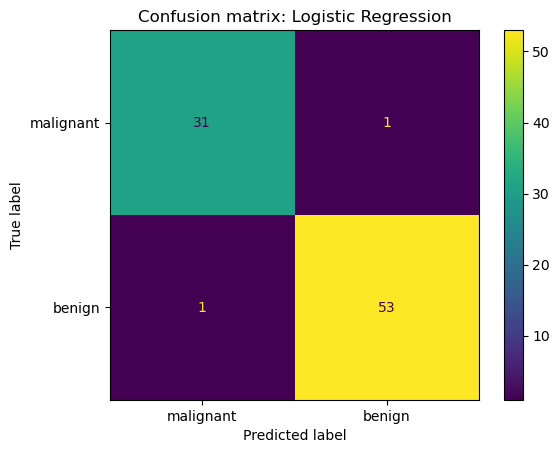

In [24]:
best_model_name = max(validation_results, key=lambda row: row[2])[0]
best_model = candidate_models[best_model_name]

best_model.fit(X_train_val, y_train_val)
test_pred = best_model.predict(X_test)

print("Best validation model:", best_model_name)
print("Final test accuracy:", round(accuracy_score(y_test, test_pred), 4))
print()
print(classification_report(y_test, test_pred, target_names=data.target_names))

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, display_labels=data.target_names)
plt.title(f"Confusion matrix: {best_model_name}")
plt.show()

---
# Part D — Hyperparameter Tuning

Hyperparameters are selected by the data analyst. We now tune models using cross-validation.

## 11. Grid search for SVM

Grid search tries all listed hyperparameter combinations.

In [25]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(random_state=RANDOM_STATE)),
])

param_grid = [
    {"svc__kernel": ["linear"], "svc__C": [0.1, 1, 10]},
    {"svc__kernel": ["rbf"], "svc__C": [0.1, 1, 10], "svc__gamma": ["scale", 0.01, 0.1]},
]

grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=1,
    return_train_score=True,
)

grid_search.fit(X_train_val, y_train_val)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 4))
print("Final test accuracy:", round(accuracy_score(y_test, grid_search.predict(X_test)), 4))

Best parameters: {'svc__C': 0.1, 'svc__kernel': 'linear'}
Best CV accuracy: 0.9855
Final test accuracy: 0.9767


In [26]:
results = grid_search.cv_results_
order = np.argsort(results["mean_test_score"])[::-1]

print("Top grid-search configurations")
print("-" * 90)
for rank, idx in enumerate(order[:8], start=1):
    print(f"{rank:>2}. mean={results['mean_test_score'][idx]:.4f}, std={results['std_test_score'][idx]:.4f}, params={results['params'][idx]}")

Top grid-search configurations
------------------------------------------------------------------------------------------
 1. mean=0.9855, std=0.0082, params={'svc__C': 0.1, 'svc__kernel': 'linear'}
 2. mean=0.9773, std=0.0120, params={'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
 3. mean=0.9752, std=0.0154, params={'svc__C': 1, 'svc__kernel': 'linear'}
 4. mean=0.9752, std=0.0105, params={'svc__C': 1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
 5. mean=0.9732, std=0.0154, params={'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
 6. mean=0.9691, std=0.0235, params={'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
 7. mean=0.9669, std=0.0119, params={'svc__C': 10, 'svc__kernel': 'linear'}
 8. mean=0.9628, std=0.0202, params={'svc__C': 1, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}


## 12. Randomized search for Random Forest

Randomized search samples a fixed number of combinations. This is useful when the search space is large.

In [28]:
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

random_param_dist = {
    "n_estimators": [30, 50, 100],
    "max_depth": [None, 3, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
}

random_search = RandomizedSearchCV(
    rf,
    random_param_dist,
    n_iter=8,
    scoring="accuracy",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

random_search.fit(X_train_val, y_train_val)

print("Best parameters:", random_search.best_params_)
print("Best CV accuracy:", round(random_search.best_score_, 4))
print("Final test accuracy:", round(accuracy_score(y_test, random_search.predict(X_test)), 4))

Best parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best CV accuracy: 0.9587
Final test accuracy: 0.9535


---
# Part E — Validation Approaches

We now implement k-fold cross-validation, leave-one-out cross-validation, and validation curves.

## 13. K-fold cross-validation

In [29]:
log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(log_reg_pipeline, X_clf, y_clf, cv=kfold, scoring="accuracy")

print("5-fold CV scores:", np.round(cv_scores, 4))
print("Mean accuracy:", round(cv_scores.mean(), 4))
print("Standard deviation:", round(cv_scores.std(), 4))

5-fold CV scores: [0.9737 0.9474 0.9649 0.9912 0.9912]
Mean accuracy: 0.9737
Standard deviation: 0.0166


## 14. Leave-One-Out Cross-Validation

LOOCV fits one model per observation. To keep the tutorial fast, we use a small stratified subset of the Iris dataset.

In [30]:
iris = load_iris()
X_iris_small, _, y_iris_small, _ = train_test_split(
    iris.data,
    iris.target,
    train_size=60,
    stratify=iris.target,
    random_state=RANDOM_STATE,
)

loo_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])

start = time.time()
loo_scores = cross_val_score(loo_model, X_iris_small, y_iris_small, cv=LeaveOneOut(), scoring="accuracy", n_jobs=1)
elapsed = time.time() - start

print("Number of LOOCV fits:", len(loo_scores))
print("LOOCV accuracy:", round(loo_scores.mean(), 4))
print("Elapsed time in seconds:", round(elapsed, 2))

Number of LOOCV fits: 60
LOOCV accuracy: 0.95
Elapsed time in seconds: 0.27


## 15. Validation curve for SVM regularization parameter `C`

In `SVC`, larger `C` usually means weaker regularization.

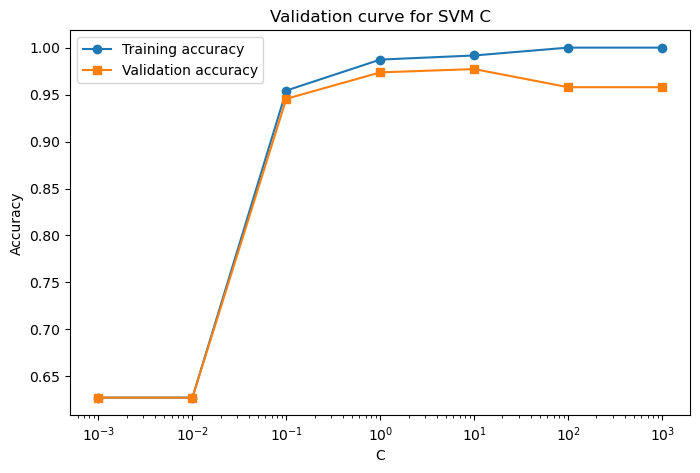

C=0.001    | Train accuracy=0.6274 | Validation accuracy=0.6274
C=0.01     | Train accuracy=0.6274 | Validation accuracy=0.6274
C=0.1      | Train accuracy=0.9543 | Validation accuracy=0.9455
C=1        | Train accuracy=0.9873 | Validation accuracy=0.9736
C=10       | Train accuracy=0.9917 | Validation accuracy=0.9772
C=100      | Train accuracy=1.0000 | Validation accuracy=0.9579
C=1000     | Train accuracy=1.0000 | Validation accuracy=0.9579


In [31]:
C_values = np.logspace(-3, 3, 7)

train_scores, valid_scores = validation_curve(
    svm_pipeline,
    X_clf,
    y_clf,
    param_name="svc__C",
    param_range=C_values,
    cv=5,
    scoring="accuracy",
    n_jobs=1,
)

plt.figure(figsize=(8, 5))
plt.semilogx(C_values, train_scores.mean(axis=1), marker="o", label="Training accuracy")
plt.semilogx(C_values, valid_scores.mean(axis=1), marker="s", label="Validation accuracy")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Validation curve for SVM C")
plt.legend()
plt.show()

for C, tr, va in zip(C_values, train_scores.mean(axis=1), valid_scores.mean(axis=1)):
    print(f"C={C:<8.4g} | Train accuracy={tr:.4f} | Validation accuracy={va:.4f}")

---
# Part F — Practical Selection Criteria

Practical questions: explainability, memory, training speed, and prediction speed.

## 16. Explainability with a shallow decision tree

In [32]:
explainable_tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
explainable_tree.fit(X_train_val, y_train_val)

print(export_text(explainable_tree, feature_names=list(data.feature_names)))
print("Test accuracy:", round(accuracy_score(y_test, explainable_tree.predict(X_test)), 4))

|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 91.56
|   |   |   |--- class: 1
|   |   |--- area error >  91.56
|   |   |   |--- class: 0
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- class: 1
|   |   |--- worst texture >  25.62
|   |   |   |--- class: 0
|--- worst radius >  16.80
|   |--- texture error <= 0.47
|   |   |--- texture error <= 0.36
|   |   |   |--- class: 0
|   |   |--- texture error >  0.36
|   |   |   |--- class: 1
|   |--- texture error >  0.47
|   |   |--- worst concavity <= 0.19
|   |   |   |--- class: 0
|   |   |--- worst concavity >  0.19
|   |   |   |--- class: 0

Test accuracy: 0.9419


## 17. Coefficients of a linear model

For linear models, coefficients can support interpretation. Interpret them carefully when features are correlated.

In [33]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])
linear_model.fit(X_train_val, y_train_val)

coefs = linear_model.named_steps["model"].coef_[0]
top_indices = np.argsort(np.abs(coefs))[::-1][:10]

print("Top 10 features by absolute coefficient magnitude")
print("-" * 65)
for idx in top_indices:
    print(f"{data.feature_names[idx]:<30} coefficient={coefs[idx]: .4f}")

Top 10 features by absolute coefficient magnitude
-----------------------------------------------------------------
worst texture                  coefficient=-1.2253
radius error                   coefficient=-1.1395
worst symmetry                 coefficient=-1.0228
worst area                     coefficient=-0.9608
worst radius                   coefficient=-0.9539
worst concave points           coefficient=-0.9532
area error                     coefficient=-0.9428
worst concavity                coefficient=-0.8794
worst smoothness               coefficient=-0.8528
worst perimeter                coefficient=-0.7656


This output ranks the 10 most influential features in the logistic regression model by the absolute size of their coefficients, so bigger absolute values mean a stronger effect on the prediction. The sign shows direction: a positive coefficient pushes predictions toward class 1, while a negative coefficient pushes toward class 0 (for this model’s class encoding). Because features were standardized, these coefficients are directly comparable in relative importance, but they still describe association, not causation, and correlated features can split or share influence.

## 18. Training speed and prediction speed

This is a simple classroom benchmark, not a rigorous systems benchmark.

In [35]:
speed_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "SVM RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
}

print(f"{'Model':<22} | {'Train time (s)':>14} | {'Predict time (s)':>16} | {'Test acc':>8}")
print("-" * 75)
for name, model in speed_models.items():
    start = time.time()
    model.fit(X_train_val, y_train_val)
    train_time = time.time() - start

    start = time.time()
    preds = model.predict(X_test)
    pred_time = time.time() - start

    acc = accuracy_score(y_test, preds)
    print(f"{name:<22} | {train_time:14.5f} | {pred_time:16.5f} | {acc:8.4f}")

Model                  | Train time (s) | Predict time (s) | Test acc
---------------------------------------------------------------------------
Logistic Regression    |        0.00675 |          0.00201 |   0.9767
KNN                    |        0.00201 |          0.00500 |   0.9651
SVM RBF                |        0.00400 |          0.00273 |   0.9767
Decision Tree          |        0.00850 |          0.00000 |   0.9419
Random Forest          |        0.17953 |          0.03145 |   0.9419


---
# Part G — Incremental Learning for Large or Streaming Data

If data cannot fit into memory, some scikit-learn estimators support incremental learning through `partial_fit`. Here we simulate mini-batch learning with `SGDClassifier`.

In [36]:
scaler = StandardScaler()
X_train_val_scaled = scaler.fit_transform(X_train_val)
X_test_scaled = scaler.transform(X_test)

sgd = SGDClassifier(loss="log_loss", alpha=0.0001, random_state=RANDOM_STATE)
classes = np.unique(y_train_val)

batch_size = 32
indices = np.arange(X_train_val_scaled.shape[0])
np.random.shuffle(indices)

for start_idx in range(0, len(indices), batch_size):
    batch_indices = indices[start_idx:start_idx + batch_size]
    X_batch = X_train_val_scaled[batch_indices]
    y_batch = y_train_val[batch_indices]

    if start_idx == 0:
        sgd.partial_fit(X_batch, y_batch, classes=classes)
    else:
        sgd.partial_fit(X_batch, y_batch)

sgd_pred = sgd.predict(X_test_scaled)
print("Incremental SGDClassifier test accuracy:", round(accuracy_score(y_test, sgd_pred), 4))

Incremental SGDClassifier test accuracy: 0.9302


---
# Part H — Reusable Workflow Template

The following cell summarizes a practical scikit-learn training workflow.

In [37]:
# 1. Load data
workflow_data = load_breast_cancer()
X = workflow_data.data
y = workflow_data.target

# 2. Split off a final test set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)

# 3. Define pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(random_state=RANDOM_STATE)),
])

# 4. Define search space
param_grid = [
    {"model__kernel": ["linear"], "model__C": [0.1, 1, 10]},
    {"model__kernel": ["rbf"], "model__C": [0.1, 1, 10], "model__gamma": ["scale", 0.01, 0.1]},
]

# 5. Tune with cross-validation
search = GridSearchCV(pipeline, param_grid, scoring="accuracy", cv=5, n_jobs=1)
search.fit(X_train_val, y_train_val)

# 6. Final test evaluation
final_predictions = search.predict(X_test)
print("Best hyperparameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_, 4))
print("Final test accuracy:", round(accuracy_score(y_test, final_predictions), 4))

Best hyperparameters: {'model__C': 0.1, 'model__kernel': 'linear'}
Best CV accuracy: 0.9855
Final test accuracy: 0.9767
